# W03 Correlation Analysis — Aido Rover Fault Determinants

## Problem Statement

This notebook applies the first stage of the Tsinghua-style determinant analysis methodology to synthetic Aido Rover telemetry data.

The main question is:

**Which sensor variables are most strongly associated with Aido Rover fault status?**

This correlation analysis will guide variable selection for the Week 3 multivariate regression model.

## 1. Import Packages

Run the install cell only if your notebook shows `ModuleNotFoundError`.

In [1]:
# Optional install cell. Run only if needed.
# %pip install pandas matplotlib scipy statsmodels

In [15]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

## 2. Load Dataset

The code below tries several common file locations, so it should work whether your notebook is in `week3/notebooks/` or another folder.

In [3]:
possible_paths = [
    Path("../data/synthetic_rover_data.csv"),
    Path("../data/synthetic rover data.csv"),
    Path("../../week1/data/synthetic_rover_data.csv"),
    Path("../../week1/data/synthetic rover data.csv"),
    Path("../../../week1/data/synthetic_rover_data.csv"),
    Path("../../../week1/data/synthetic rover data.csv"),
]

data_path = None

for path in possible_paths:
    if path.exists():
        data_path = path
        break

if data_path is None:
    raise FileNotFoundError(
        "Could not find the synthetic rover data CSV. "
        "Please check the file path and update possible_paths."
    )

print("Loaded data from:", data_path)

df = pd.read_csv(data_path)
df.head()

Loaded data from: ..\..\week1\data\synthetic_rover_data.csv


,timestamp,unit_id,gps_lat,gps_lon,lidar_dist,battery_soc,torque_fl,torque_fr,torque_rl,torque_rr,ambient_temp,fault_label
0,2026-06-22 00:00:00,ROVER_01,37.387102,-121.979485,3.286,72.46,7.899,9.458,9.574,10.687,26.02,0
1,2026-06-22 00:01:00,ROVER_18,37.392078,-121.958254,2.843,57.83,3.922,8.088,5.485,4.936,19.68,0
2,2026-06-22 00:02:00,ROVER_11,37.395329,-121.966144,3.569,59.29,10.364,9.169,10.114,10.455,23.05,0
3,2026-06-22 00:03:00,ROVER_20,37.394625,-121.978246,3.284,70.02,5.074,10.203,6.993,8.247,20.36,0
4,2026-06-22 00:04:00,ROVER_12,37.392388,-121.964007,1.909,56.78,9.004,8.305,8.141,9.586,29.57,0


## 3. Basic Data Check

In [4]:
print("Dataset shape:", df.shape)

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nFault label counts:")
print(df["fault_label"].value_counts())

print("\nFault rate:", round(df["fault_label"].mean(), 4))

Dataset shape: (15000, 12)

Data types:
timestamp           str
unit_id             str
gps_lat         float64
gps_lon         float64
lidar_dist      float64
battery_soc     float64
torque_fl       float64
torque_fr       float64
torque_rl       float64
torque_rr       float64
ambient_temp    float64
fault_label       int64
dtype: object

Missing values:
timestamp       0
unit_id         0
gps_lat         0
gps_lon         0
lidar_dist      0
battery_soc     0
torque_fl       0
torque_fr       0
torque_rl       0
torque_rr       0
ambient_temp    0
fault_label     0
dtype: int64

Fault label counts:
fault_label
0    13138
1     1862
Name: count, dtype: int64

Fault rate: 0.1241


## 4. Define Numeric Sensor Variables

In [5]:
sensor_columns = [
    "gps_lat",
    "gps_lon",
    "lidar_dist",
    "battery_soc",
    "torque_fl",
    "torque_fr",
    "torque_rl",
    "torque_rr",
    "ambient_temp"
]

target = "fault_label"

df[sensor_columns + [target]].describe()

,gps_lat,gps_lon,lidar_dist,battery_soc,torque_fl,torque_fr,torque_rl,torque_rr,ambient_temp,fault_label
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,37.387610,-121.972025,3.185068,64.328101,10.952687,10.968162,10.955092,10.941116,23.990436,0.124133
std,0.010000,0.009937,1.153512,17.412071,4.662813,4.662651,4.669045,4.671350,4.954226,0.329745
min,37.353479,-122.009054,0.100000,0.000000,-2.529000,-3.642000,-2.117000,-2.603000,6.310000,0.000000
25%,37.380932,-121.978706,2.489000,53.200000,7.965750,7.995000,8.001750,7.931750,20.610000,0.000000
50%,37.387637,-121.971982,3.061000,65.480000,10.421000,10.420500,10.395500,10.409000,24.005000,0.000000
75%,37.394287,-121.965261,3.684250,76.482500,13.089000,13.123000,13.079250,13.060250,27.340000,0.000000
max,37.429076,-121.928851,12.977000,100.000000,44.309000,41.229000,40.893000,42.593000,41.800000,1.000000


## 5. Mean Comparison by Fault Label

This step checks whether normal rows and fault rows differ in their average sensor values.

In [6]:
group_means = df.groupby(target)[sensor_columns].mean().round(3)
group_means

,gps_lat,gps_lon,lidar_dist,battery_soc,torque_fl,torque_fr,torque_rl,torque_rr,ambient_temp
fault_label,,,,,,,,,
0,37.388,-121.972,2.99,67.996,9.967,9.972,9.966,9.952,24.006
1,37.388,-121.972,4.56,38.449,17.909,17.994,17.935,17.917,23.881


## 6. Pearson Correlation with Fault Label

Because `fault_label` is binary, this is equivalent to checking linear association between each sensor variable and fault status. This is a screening step, not the final model.

In [16]:
correlation_results = []

for col in sensor_columns:
    r, p_value = stats.pearsonr(df[col], df[target])
    correlation_results.append({
        "feature": col,
        "pearson_r": r,
        "abs_r": abs(r),
        "p_value": p_value
    })

corr_table = pd.DataFrame(correlation_results)
corr_table = corr_table.sort_values("abs_r", ascending=False).reset_index(drop=True)

corr_table

,feature,pearson_r,abs_r,p_value
0,torque_fr,0.567319,0.567319,0.000000
1,torque_rl,0.562847,0.562847,0.000000
2,torque_rr,0.562190,0.562190,0.000000
3,torque_fl,0.561672,0.561672,0.000000
4,battery_soc,-0.559559,0.559559,0.000000
5,lidar_dist,0.448805,0.448805,0.000000
6,ambient_temp,-0.008346,0.008346,0.306704
7,gps_lat,-0.003060,0.003060,0.707842
8,gps_lon,0.000708,0.000708,0.930919


## 7. Candidate Predictor Selection

A feature is treated as a candidate predictor if:

- `abs(Pearson r) > 0.10`
- `p_value < 0.05`

In [20]:
candidate_predictors = corr_table[
    (corr_table["abs_r"] > 0.10) & (corr_table["p_value"] < 0.05)
]["feature"].tolist()

print("Candidate predictors:")
candidate_predictors

Candidate predictors:


['torque_fr',
 'torque_rl',
 'torque_rr',
 'torque_fl',
 'battery_soc',
 'lidar_dist']

## 8. Correlation Heatmap

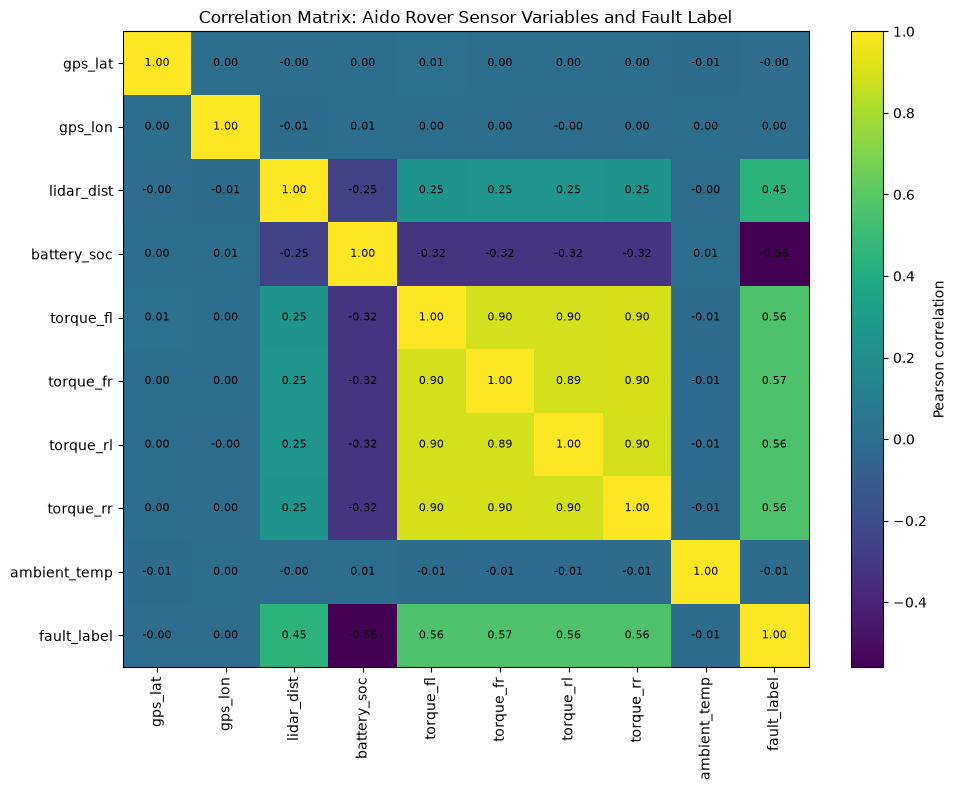

In [9]:
corr_matrix = df[sensor_columns + [target]].corr()

plt.figure(figsize=(10, 8))
plt.imshow(corr_matrix, aspect="auto")
plt.colorbar(label="Pearson correlation")
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.index)), corr_matrix.index)
plt.title("Correlation Matrix: Aido Rover Sensor Variables and Fault Label")

for i in range(len(corr_matrix.index)):
    for j in range(len(corr_matrix.columns)):
        plt.text(j, i, f"{corr_matrix.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)

plt.tight_layout()
plt.show()

## 9. Top Predictors vs. Fault Label

Because the outcome is binary, the plots use small vertical jitter so that normal and fault rows are easier to see.

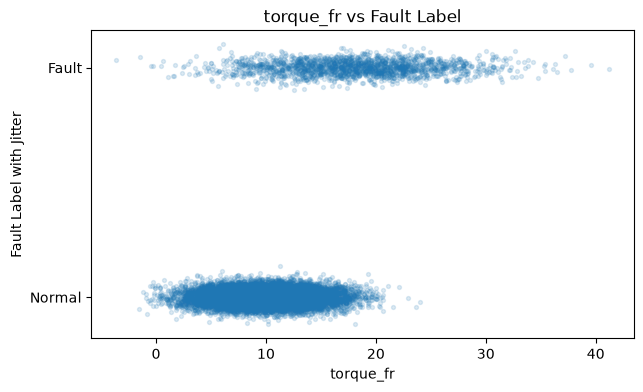

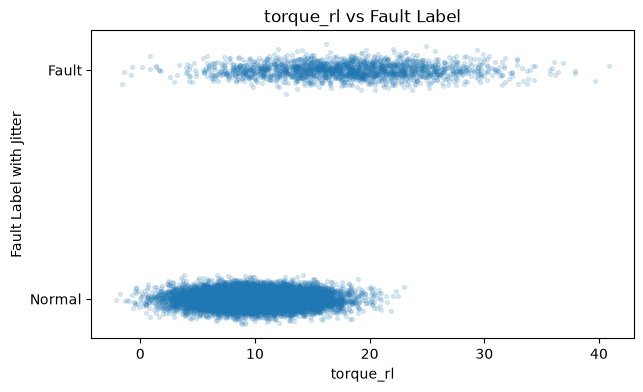

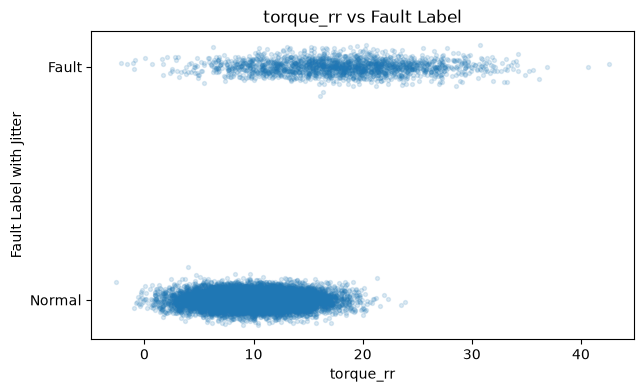

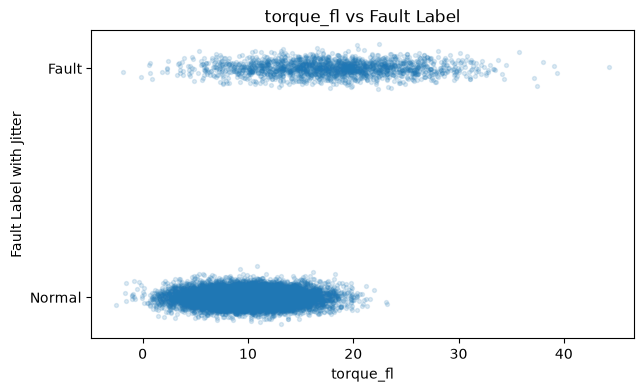

In [18]:
top_features = corr_table.head(4)["feature"].tolist()

for col in top_features:
    plt.figure(figsize=(7, 4))
    jitter = np.random.normal(0, 0.03, size=len(df))
    plt.scatter(df[col], df[target] + jitter, alpha=0.15, s=8)
    plt.title(f"{col} vs Fault Label")
    plt.xlabel(col)
    plt.ylabel("Fault Label with Jitter")
    plt.yticks([0, 1], ["Normal", "Fault"])
    plt.show()

## 10. Multicollinearity Check

Predictors that are highly correlated with each other can create unstable regression coefficients.

The following check identifies predictor pairs with absolute correlation above 0.70.

In [11]:
predictor_corr = df[sensor_columns].corr()

high_corr_pairs = []

for i in range(len(predictor_corr.columns)):
    for j in range(i + 1, len(predictor_corr.columns)):
        col1 = predictor_corr.columns[i]
        col2 = predictor_corr.columns[j]
        r = predictor_corr.iloc[i, j]
        if abs(r) > 0.70:
            high_corr_pairs.append({
                "feature_1": col1,
                "feature_2": col2,
                "correlation": r
            })

high_corr_df = pd.DataFrame(high_corr_pairs)
high_corr_df

,feature_1,feature_2,correlation
0,torque_fl,torque_fr,0.895487
1,torque_fl,torque_rl,0.895557
2,torque_fl,torque_rr,0.896542
3,torque_fr,torque_rl,0.894264
4,torque_fr,torque_rr,0.896544
5,torque_rl,torque_rr,0.895435


## 11. Interpretation

Write your final interpretation after running the notebook.

Suggested points:

- Which features have the strongest correlation with `fault_label`?
- Are the torque variables highly correlated with one another?
- Which variables should be included in the regression model?
- Which variables may need to be combined into a single engineered feature such as `torque_mean`?

In [19]:
print("Top correlation candidates:")
display(corr_table.head(6))

print("\nHigh multicollinearity pairs:")
display(high_corr_df)

Top correlation candidates:


,feature,pearson_r,abs_r,p_value
0,torque_fr,0.567319,0.567319,0.0
1,torque_rl,0.562847,0.562847,0.0
2,torque_rr,0.562190,0.562190,0.0
3,torque_fl,0.561672,0.561672,0.0
4,battery_soc,-0.559559,0.559559,0.0
5,lidar_dist,0.448805,0.448805,0.0



High multicollinearity pairs:


,feature_1,feature_2,correlation
0,torque_fl,torque_fr,0.895487
1,torque_fl,torque_rl,0.895557
2,torque_fl,torque_rr,0.896542
3,torque_fr,torque_rl,0.894264
4,torque_fr,torque_rr,0.896544
5,torque_rl,torque_rr,0.895435


## Preliminary Conclusion

Based on the correlation screening, the most important candidate predictors for Aido Rover fault status are expected to include:

- battery state of charge
- LiDAR distance
- wheel torque variables

If the four wheel torque variables are highly correlated with each other, the Week 3 regression model can use an engineered feature such as `torque_mean` to reduce multicollinearity.

This follows the Tsinghua-style methodology: first identify candidate predictors through exploratory and correlation analysis, then test them in a multivariate regression model.